# 03 - Modeling : Baseline LightGBM

**Étape CRISP-DM : Modeling**

Split **temporel** (pas aléatoire) sur `TransactionDT` : 80% des transactions les plus anciennes
pour l'entraînement, 20% les plus récentes pour le test. Un split aléatoire créerait une fuite
d'information (patterns utilisateurs/cartes récurrents dans le temps) et surestimerait la
performance réelle en production, où le modèle prédit toujours sur des transactions futures.

Métriques : le dataset est déséquilibré (3,50% de fraude, ratio 1:28) donc l'accuracy est inutile.
On suit **PR-AUC** (average precision, la plus informative ici) et **ROC-AUC** en complément.

In [1]:
import os
import sys

import mlflow
import mlflow.lightgbm
import pandas as pd

sys.path.append(os.path.join(".."))

from src.pipeline import get_column_types, TARGET_COL
from src.models import time_based_split, get_feature_columns, train_lightgbm, evaluate_model, DEFAULT_PARAMS

DATA_PATH = os.path.join("..", "data", "processed", "train_clean.parquet")
MLFLOW_DB_PATH = os.path.abspath(os.path.join("..", "mlflow.db")).replace("\\", "/")

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH}")
mlflow.set_experiment("fraudshield-baseline")

<Experiment: artifact_location='file:C:/Users/MONTI VINCENT LOIC/Desktop/FraudShield/notebooks/mlruns/1', creation_time=1786045271462, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1786045271462, lifecycle_stage='active', name='fraudshield-baseline', tags={}, trace_location=None, workspace='default'>

In [2]:
import gc

df = pd.read_parquet(DATA_PATH)
print(f"Dataset charge : {df.shape}")

feature_cols = get_feature_columns(df)
categorical_cols, _ = get_column_types(df)

train, test = time_based_split(df, test_size=0.2)
train = train.copy()
test = test.copy()

del df
gc.collect()

print(f"Train : {train.shape} | periode DT [{train['TransactionDT'].min()}, {train['TransactionDT'].max()}]")
print(f"Test  : {test.shape} | periode DT [{test['TransactionDT'].min()}, {test['TransactionDT'].max()}]")
print(f"Taux de fraude train : {train[TARGET_COL].mean():.2%}")
print(f"Taux de fraude test  : {test[TARGET_COL].mean():.2%}")

Dataset charge : (590540, 435)


Train : (472432, 435) | periode DT [86400, 12192842]
Test  : (118108, 435) | periode DT [12192900, 15811131]
Taux de fraude train : 3.51%
Taux de fraude test  : 3.44%


In [3]:
print(f"Nombre de features : {len(feature_cols)}")
print(f"Dont categorielles : {len([c for c in categorical_cols if c in feature_cols])}")

Nombre de features : 432
Dont categorielles : 60


In [4]:
with mlflow.start_run(run_name="lightgbm-baseline"):
    mlflow.log_params(DEFAULT_PARAMS)
    mlflow.log_param("n_features", len(feature_cols))
    mlflow.log_param("split_strategy", "time_based_80_20")

    model = train_lightgbm(train, feature_cols, categorical_cols)
    metrics = evaluate_model(model, test, feature_cols)

    mlflow.log_metric("roc_auc", metrics["roc_auc"])
    mlflow.log_metric("pr_auc", metrics["pr_auc"])
    mlflow.lightgbm.log_model(model, artifact_path="model")

    print(f"ROC-AUC : {metrics['roc_auc']:.4f}")
    print(f"PR-AUC  : {metrics['pr_auc']:.4f}")
    print(f"\nMatrice de confusion (seuil 0.5) :")
    print(pd.DataFrame(
        metrics["confusion_matrix"],
        index=["Vrai: non-fraude", "Vrai: fraude"],
        columns=["Predit: non-fraude", "Predit: fraude"],
    ))
    print(f"\n{metrics['classification_report']}")

[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN


[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN


[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.590918 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20146
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 431
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


2026/08/06 20:58:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


ROC-AUC : 0.8976
PR-AUC  : 0.5713

Matrice de confusion (seuil 0.5) :
                  Predit: non-fraude  Predit: fraude
Vrai: non-fraude              111932            2112
Vrai: fraude                    1758            2306

              precision    recall  f1-score   support

           0      0.985     0.981     0.983    114044
           1      0.522     0.567     0.544      4064

    accuracy                          0.967    118108
   macro avg      0.753     0.774     0.763    118108
weighted avg      0.969     0.967     0.968    118108



In [5]:
from src.models import save_model

MODEL_PATH = os.path.join("..", "models", "lightgbm_baseline.pkl")
save_model(model, MODEL_PATH)
print(f"Modele sauvegarde : {MODEL_PATH}")

Modele sauvegarde : ..\models\lightgbm_baseline.pkl


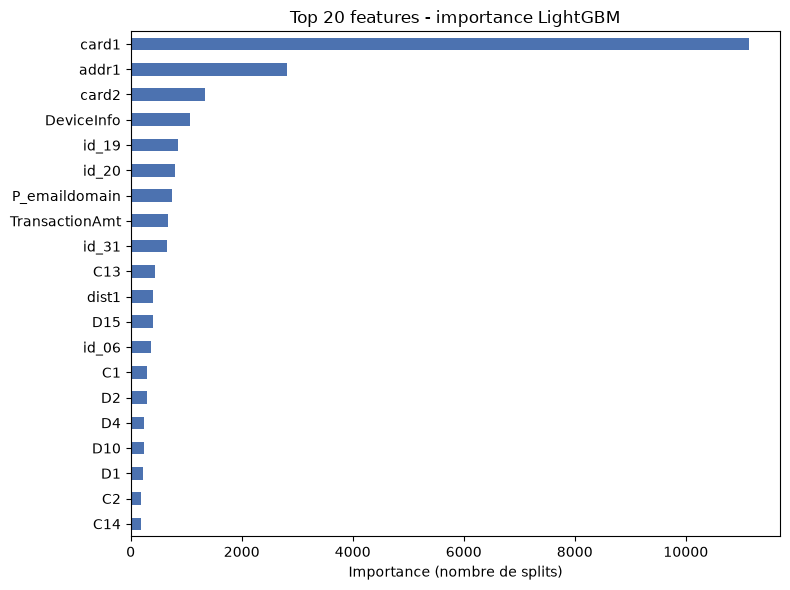

In [6]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=feature_cols)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title("Top 20 features - importance LightGBM")
ax.set_xlabel("Importance (nombre de splits)")
plt.tight_layout()
plt.show()